# M4 · XGBoost (gradient boosting challenger)

**Question:** M3 (LightGBM) clearly beat Logistic Regression. Is that result real, or specific to one library and its settings?

XGBoost uses the same idea (shallow trees built one after another, each correcting the previous trees' mistakes) with a different engine: trees grow **level by level** (`max_depth`), whereas LightGBM grows them leaf by leaf.

Versions: **A** (189 features), **B** (147, no LendingClub grades; deployable). Fit on train, early-stop and choose on validation, **test sealed**. Full plan: `IMPLEMENTATION_PLAN.md`.

## 1. Setup

In [1]:
import gc, json, os, sys, time, platform
from pathlib import Path

import numpy as np
import pandas as pd
import sklearn
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "modeling").is_dir())
sys.path.insert(0, str(ROOT))
from src.modeling import evaluation as ev

ON_KAGGLE = Path("/kaggle/input").exists()
if ON_KAGGLE:   # data comes from the private input dataset; everything else uses the repo layout
    data_dir = next(Path("/kaggle/input").rglob("X_train.parquet")).parent
    ev.DATA_DIR, ev.METADATA_PATH = data_dir, data_dir / "metadata_v2.json"

RESULTS = ROOT / "models" / "M4_xgboost" / "results"
RESULTS.mkdir(parents=True, exist_ok=True)
SEED, N_TRIALS, MAX_ROUNDS, EARLY_STOP, SEARCH_LR = 42, 40, 5000, 100, 0.05
print("Running on:", "Kaggle" if ON_KAGGLE else "local machine", "| data:", ev.DATA_DIR)
print("Python", platform.python_version(), "| pandas", pd.__version__, "| scikit-learn", sklearn.__version__,
      "| xgboost", xgb.__version__, "| CPU cores", os.cpu_count())

Running on: Kaggle | data: /kaggle/input/datasets/mitanshkanani/credit-risk-model-inputs
Python 3.13.15 | pandas 2.3.3 | scikit-learn 1.6.1 | xgboost 3.4.1 | CPU cores 4


## 2. Load data and define versions A and B (same feature sets as M1-M3)

In [2]:
X_train, y_train_frame = ev.load_split("train")
X_val, y_val_frame = ev.load_split("validation")
y_train = y_train_frame["target"].astype(int).to_numpy()
y_val = y_val_frame["target"].astype(int).to_numpy()
meta = json.loads(ev.METADATA_PATH.read_text(encoding="utf-8"))
lc_risk = set(meta["feature_groups"]["lc_risk_features"])
features = {
    "A": [c for c in X_train.columns if c != "fico_range_high"],
    "B": [c for c in X_train.columns if c != "fico_range_high" and c not in lc_risk],
}
for v, cols in features.items():
    print(f"Version {v}: {len(cols)} features")
print(f"train {X_train.shape}, default rate {y_train.mean():.4f} | validation {X_val.shape}, default rate {y_val.mean():.4f}")

Version A: 189 features
Version B: 147 features
train (388124, 190), default rate 0.1724 | validation (162745, 190), default rate 0.2035


## 3. Training helper
XGBoost core API with `DMatrix`. Objective `binary:logistic`, `tree_method="hist"`. Training stops when **validation AUC** has not improved for 100 rounds (max 5,000).

In [3]:
BASE = dict(objective="binary:logistic", eval_metric=["logloss", "auc"], tree_method="hist",
            seed=SEED, nthread=os.cpu_count(), verbosity=0)
_dmatrices = {}

def dmatrices(version):
    if version not in _dmatrices:
        cols = features[version]
        _dmatrices[version] = (xgb.DMatrix(X_train[cols], label=y_train, feature_names=cols),
                               xgb.DMatrix(X_val[cols], label=y_val, feature_names=cols))
    return _dmatrices[version]

def train(version, params):
    dtrain, dval = dmatrices(version)
    evals = {}
    stop = xgb.callback.EarlyStopping(rounds=EARLY_STOP, metric_name="auc", data_name="validation",
                                      maximize=True, save_best=False)
    booster = xgb.train({**BASE, **params}, dtrain, num_boost_round=MAX_ROUNDS, evals=[(dval, "validation")],
                        evals_result=evals, callbacks=[stop], verbose_eval=False)
    return booster, evals

def predict(booster, version, X, **kwargs):
    cols = features[version]
    return booster.predict(xgb.DMatrix(X[cols], feature_names=cols),
                           iteration_range=(0, booster.best_iteration + 1), **kwargs)

## 4. Random search: 40 settings per version (learning rate 0.05)
Trial 0 uses XGBoost-style defaults (depth 6). The same 40 settings are tried for A and B.

In [4]:
rng = np.random.default_rng(SEED)
def log_uniform(low, high):
    return float(np.exp(rng.uniform(np.log(low), np.log(high))))

configs = [{"max_depth": 6, "min_child_weight": 1.0, "subsample": 0.8, "colsample_bytree": 0.7,
            "reg_lambda": 1.0, "reg_alpha": 0.0, "gamma": 0.0}]
for _ in range(N_TRIALS - 1):
    configs.append({"max_depth": int(rng.integers(3, 11)), "min_child_weight": round(log_uniform(1, 200), 3),
                    "subsample": round(rng.uniform(0.5, 1.0), 3), "colsample_bytree": round(rng.uniform(0.4, 1.0), 3),
                    "reg_lambda": log_uniform(1e-3, 10), "reg_alpha": log_uniform(1e-4, 10),
                    "gamma": round(rng.uniform(0.0, 1.0), 3)})

rows = []
for version in ("A", "B"):
    start_version = time.time()
    for trial, cfg in enumerate(configs):
        start = time.time()
        booster, _ = train(version, {**cfg, "learning_rate": SEARCH_LR})
        card = ev.report_card(y_val, predict(booster, version, X_val))
        rows.append({"version": version, "trial": trial, **cfg, "best_iteration": booster.best_iteration + 1,
                     "val_roc_auc": card["roc_auc"], "val_ks": card["ks"], "val_brier": card["brier"],
                     "val_log_loss": card["log_loss"], "val_mean_pd": card["mean_pd"], "seconds": round(time.time() - start, 1)})
        del booster
        if trial % 10 == 9 or trial == len(configs) - 1:
            best = max(r["val_roc_auc"] for r in rows if r["version"] == version)
            print(f"{version}: {trial + 1}/{len(configs)} settings done, best validation AUC so far {best:.4f}")
    print(f"Version {version} search: {(time.time() - start_version) / 60:.1f} min")
tuning = pd.DataFrame(rows)
tuning.sort_values(["version", "val_roc_auc"], ascending=[True, False]).groupby("version").head(8).round(4)

A: 10/40 settings done, best validation AUC so far 0.7412
A: 20/40 settings done, best validation AUC so far 0.7412
A: 30/40 settings done, best validation AUC so far 0.7412
A: 40/40 settings done, best validation AUC so far 0.7412
Version A search: 68.9 min
B: 10/40 settings done, best validation AUC so far 0.7356
B: 20/40 settings done, best validation AUC so far 0.7359
B: 30/40 settings done, best validation AUC so far 0.7359
B: 40/40 settings done, best validation AUC so far 0.7359
Version B search: 59.9 min


,version,trial,max_depth,min_child_weight,subsample,colsample_bytree,reg_lambda,reg_alpha,gamma,best_iteration,val_roc_auc,val_ks,val_brier,val_log_loss,val_mean_pd,seconds
1,A,1,3,10.230,0.929,0.818,0.0024,7.5529,0.761,2334,0.7412,0.3517,0.1423,0.4450,0.1789,242.8
24,A,24,7,79.675,0.948,0.484,0.1645,0.0003,0.672,620,0.7411,0.3499,0.1422,0.4448,0.1807,98.3
25,A,25,3,32.912,0.863,0.861,0.0027,3.8024,0.230,1838,0.7411,0.3505,0.1423,0.4452,0.1779,199.9
17,A,17,5,44.626,0.725,0.563,0.0024,3.2585,0.456,935,0.7410,0.3504,0.1423,0.4449,0.1802,124.9
36,A,36,6,28.760,0.553,0.484,0.0475,6.7789,0.596,665,0.7410,0.3487,0.1423,0.4449,0.1804,105.0
26,A,26,5,1.219,0.777,0.623,2.0853,1.0997,0.317,819,0.7409,0.3507,0.1423,0.4452,0.1789,113.5
12,A,12,7,91.983,0.617,0.435,0.0134,0.0029,0.662,643,0.7409,0.3510,0.1422,0.4448,0.1813,105.9
37,A,37,4,70.935,0.734,0.871,0.0012,0.0004,0.829,1224,0.7408,0.3494,0.1424,0.4455,0.1777,144.5
57,B,17,5,44.626,0.725,0.563,0.0024,3.2585,0.456,895,0.7359,0.3442,0.1427,0.4466,0.1869,99.1
41,B,1,3,10.230,0.929,0.818,0.0024,7.5529,0.761,2584,0.7356,0.3415,0.1427,0.4466,0.1874,221.2


### Selection rule
Highest validation ROC-AUC. Within 0.0005 of the best, prefer the smaller `max_depth` (simpler trees).

In [5]:
PARAM_KEYS = ["max_depth", "min_child_weight", "subsample", "colsample_bytree", "reg_lambda", "reg_alpha", "gamma"]
chosen = {}
for version, part in tuning.groupby("version"):
    best = part["val_roc_auc"].max()
    pick = part[part["val_roc_auc"] >= best - 0.0005].sort_values(["max_depth", "val_roc_auc"], ascending=[True, False]).iloc[0]
    chosen[version] = {k: (int(pick[k]) if k == "max_depth" else float(pick[k])) for k in PARAM_KEYS}
    print(f"Version {version}: best AUC {best:.4f}; chosen trial {int(pick['trial'])} (AUC {pick['val_roc_auc']:.4f}, "
          f"{int(pick['best_iteration'])} rounds): {chosen[version]}")
baseline = tuning[tuning.trial == 0].set_index("version")["val_roc_auc"]
print("\nDefault-style baseline (trial 0):", baseline.round(4).to_dict())

Version A: best AUC 0.7412; chosen trial 1 (AUC 0.7412, 2334 rounds): {'max_depth': 3, 'min_child_weight': 10.23, 'subsample': 0.929, 'colsample_bytree': 0.818, 'reg_lambda': 0.0023807258718953534, 'reg_alpha': 7.552865626115626, 'gamma': 0.761}
Version B: best AUC 0.7359; chosen trial 1 (AUC 0.7356, 2584 rounds): {'max_depth': 3, 'min_child_weight': 10.23, 'subsample': 0.929, 'colsample_bytree': 0.818, 'reg_lambda': 0.0023807258718953534, 'reg_alpha': 7.552865626115626, 'gamma': 0.761}

Default-style baseline (trial 0): {'A': 0.7398, 'B': 0.7347}


## 5. Follow-up experiments
1. **Learning rate 0.02**: kept only if validation AUC improves by at least 0.0005.
2. **`scale_pos_weight`** = repaid / defaults (XGBoost's way to up-weight defaults).
3. **Monotonic constraints (B)**: FICO ↓, DTI ↑, income ↓, 60-month term ↑, recent inquiries ↑, revolving utilisation ↑ risk.

In [6]:
experiments, models, evals_by_model, final_lr, fit_seconds = [], {}, {}, {}, {}

def record(name, version, booster, note):
    card = ev.report_card(y_val, predict(booster, version, X_val))
    experiments.append({"experiment": name, "version": version, "rounds": booster.best_iteration + 1,
                        "val_roc_auc": card["roc_auc"], "val_ks": card["ks"], "val_brier": card["brier"],
                        "val_log_loss": card["log_loss"], "val_mean_pd": card["mean_pd"], "note": note})
    return card

def timed_train(version, params):
    start = time.time()
    booster, evals = train(version, params)
    return booster, evals, time.time() - start

spw = float((y_train == 0).sum() / (y_train == 1).sum())
for version in ("A", "B"):
    b05, e05, t05 = timed_train(version, {**chosen[version], "learning_rate": 0.05})
    c05 = record("chosen, lr 0.05", version, b05, "search setting")
    b02, e02, t02 = timed_train(version, {**chosen[version], "learning_rate": 0.02})
    c02 = record("chosen, lr 0.02", version, b02, "finer steps")
    if c02["roc_auc"] >= c05["roc_auc"] + 0.0005:
        models[version], evals_by_model[version], final_lr[version], fit_seconds[version] = b02, e02, 0.02, t02
    else:
        models[version], evals_by_model[version], final_lr[version], fit_seconds[version] = b05, e05, 0.05, t05
    bw, _ = train(version, {**chosen[version], "learning_rate": final_lr[version], "scale_pos_weight": spw})
    record("scale_pos_weight", version, bw, f"{spw:.2f}")
    del bw; gc.collect()

MONOTONE = {"fico_range_low": -1, "dti": +1, "annual_inc": -1, "term_months": +1, "inq_last_6mths": +1, "revol_util": +1}
features["B-mono"] = features["B"]
_dmatrices["B-mono"] = dmatrices("B")
mono = "(" + ",".join(str(MONOTONE.get(c, 0)) for c in features["B"]) + ")"
bm, em, tm = timed_train("B-mono", {**chosen["B"], "learning_rate": final_lr["B"], "monotone_constraints": mono})
record("monotonic constraints", "B", bm, ", ".join(f"{k} {'+' if v > 0 else '-'}" for k, v in MONOTONE.items()))
models["B-mono"], evals_by_model["B-mono"], final_lr["B-mono"], fit_seconds["B-mono"] = bm, em, final_lr["B"], tm
experiments = pd.DataFrame(experiments)
print("Final learning rate:", final_lr, "| final fit seconds:", {k: round(v) for k, v in fit_seconds.items()})
experiments.round(4)

Final learning rate: {'A': 0.05, 'B': 0.05, 'B-mono': 0.05} | final fit seconds: {'A': 241, 'B': 221, 'B-mono': 160}


,experiment,version,rounds,val_roc_auc,val_ks,val_brier,val_log_loss,val_mean_pd,note
0,"chosen, lr 0.05",A,2334,0.7412,0.3517,0.1423,0.4450,0.1789,search setting
1,"chosen, lr 0.02",A,4704,0.7412,0.3510,0.1423,0.4451,0.1783,finer steps
2,scale_pos_weight,A,1558,0.7405,0.3505,0.2059,0.5957,0.4449,4.80
3,"chosen, lr 0.05",B,2584,0.7356,0.3415,0.1427,0.4466,0.1874,search setting
4,"chosen, lr 0.02",B,4984,0.7356,0.3411,0.1427,0.4467,0.1873,finer steps
5,scale_pos_weight,B,2209,0.7350,0.3412,0.2160,0.6200,0.4650,4.80
6,monotonic constraints,B,1790,0.7346,0.3400,0.1429,0.4472,0.1869,"fico_range_low -, dti +, annual_inc -, term_mo..."


## 6. Score the final models

In [7]:
preds, cards = {}, {}
for name, booster in models.items():
    preds[name] = {"train": predict(booster, name, X_train), "validation": predict(booster, name, X_val)}
    cards[name] = {s: ev.report_card(y, preds[name][s]) for s, y in (("train", y_train), ("validation", y_val))}

board = pd.read_csv(ev.LEADERBOARD_PATH)
keys = ["roc_auc", "ks", "pr_auc", "brier", "log_loss", "mean_pd", "calibration_gap"]
def board_row(model, version, split="validation"):
    r = board[(board.model == model) & (board.version == version) & (board.split == split)].iloc[0]
    return {k: r[k] for k in keys}
compare = pd.DataFrame({
    "M1-A": board_row("M1", "A"), "M3-A": board_row("M3", "A"), "M4-A": {k: cards["A"]["validation"][k] for k in keys},
    "M1-B": board_row("M1", "B"), "M3-B": board_row("M3", "B"), "M4-B": {k: cards["B"]["validation"][k] for k in keys},
    "M3-B-mono": board_row("M3", "B-mono"), "M4-B-mono": {k: cards["B-mono"]["validation"][k] for k in keys},
    "M4-B (train)": {k: cards["B"]["train"][k] for k in keys},
})
print("Validation unless marked")
compare.astype(float).round(4)

Validation unless marked


,M1-A,M3-A,M4-A,M1-B,M3-B,M4-B,M3-B-mono,M4-B-mono,M4-B (train)
roc_auc,0.7335,0.7414,0.7412,0.7252,0.7362,0.7356,0.7354,0.7346,0.7471
ks,0.3421,0.3519,0.3517,0.3262,0.3415,0.3415,0.3400,0.3400,0.3624
pr_auc,0.4120,0.4250,0.4248,0.4045,0.4210,0.4201,0.4201,0.4193,0.3892
brier,0.1445,0.1422,0.1423,0.1449,0.1426,0.1427,0.1428,0.1429,0.1255
log_loss,0.4506,0.4448,0.4450,0.4529,0.4463,0.4466,0.4467,0.4472,0.4023
mean_pd,0.1773,0.1792,0.1789,0.1837,0.1869,0.1874,0.1870,0.1869,0.1725
calibration_gap,-0.0262,-0.0243,-0.0246,-0.0198,-0.0167,-0.0161,-0.0165,-0.0166,0.0000


## 7. Head-to-head with M3 (LightGBM)

In [8]:
m3_pred = pd.read_parquet(ROOT / "models" / "M3_lightgbm" / "results" / "m3_validation_pd.parquet")
ids = y_val_frame["id"].astype(str).to_numpy()
assert (m3_pred["id"].astype(str).to_numpy() == ids).all()
h2h = []
for name, m3_col in (("A", "pd_m3_A"), ("B", "pd_m3_B"), ("B-mono", "pd_m3_B_mono")):
    p3, p4 = m3_pred[m3_col].to_numpy(), preds[name]["validation"]
    blend = (p3 + p4) / 2
    h2h.append({"version": name, "M3 ROC-AUC": roc_auc_score(y_val, p3), "M4 ROC-AUC": roc_auc_score(y_val, p4),
                "M4 - M3": roc_auc_score(y_val, p4) - roc_auc_score(y_val, p3),
                "M3 Brier": ev.report_card(y_val, p3)["brier"], "M4 Brier": cards[name]["validation"]["brier"],
                "Spearman(M3, M4)": pd.Series(p3).corr(pd.Series(p4), method="spearman"),
                "average of M3+M4 ROC-AUC (info)": roc_auc_score(y_val, blend)})
h2h = pd.DataFrame(h2h)
h2h.round(4)

,version,M3 ROC-AUC,M4 ROC-AUC,M4 - M3,M3 Brier,M4 Brier,"Spearman(M3, M4)",average of M3+M4 ROC-AUC (info)
0,A,0.7414,0.7412,-0.0002,0.1422,0.1423,0.9918,0.7417
1,B,0.7362,0.7356,-0.0006,0.1426,0.1427,0.9899,0.7365
2,B-mono,0.7354,0.7346,-0.0009,0.1428,0.1429,0.9912,0.7355


## 8. Sanity checks

In [9]:
m0 = board_row("M0", "A")
checks = []
for name in models:
    val, tr = cards[name]["validation"], cards[name]["train"]
    checks += [
        (name, "early stopping triggered (< max rounds)", models[name].best_iteration + 1 < MAX_ROUNDS, f"{models[name].best_iteration + 1} rounds"),
        (name, "beats M0 ROC-AUC and Brier", val["roc_auc"] > m0["roc_auc"] and val["brier"] < m0["brier"],
         f"AUC {val['roc_auc']:.4f}, Brier {val['brier']:.4f}"),
        (name, "below 0.80 leakage flag", val["roc_auc"] < 0.80, f"{val['roc_auc']:.4f}"),
        (name, "train vs validation ROC-AUC (info)", True, f"{tr['roc_auc']:.4f} vs {val['roc_auc']:.4f}"),
    ]
pd.DataFrame(checks, columns=["model", "check", "passed", "detail"])

,model,check,passed,detail
0,A,early stopping triggered (< max rounds),True,2334 rounds
1,A,beats M0 ROC-AUC and Brier,True,"AUC 0.7412, Brier 0.1423"
2,A,below 0.80 leakage flag,True,0.7412
3,A,train vs validation ROC-AUC (info),True,0.7476 vs 0.7412
4,B,early stopping triggered (< max rounds),True,2584 rounds
5,B,beats M0 ROC-AUC and Brier,True,"AUC 0.7356, Brier 0.1427"
6,B,below 0.80 leakage flag,True,0.7356
7,B,train vs validation ROC-AUC (info),True,0.7471 vs 0.7356
8,B-mono,early stopping triggered (< max rounds),True,1790 rounds
9,B-mono,beats M0 ROC-AUC and Brier,True,"AUC 0.7346, Brier 0.1429"


## 9. Learning curve: validation AUC per boosting round

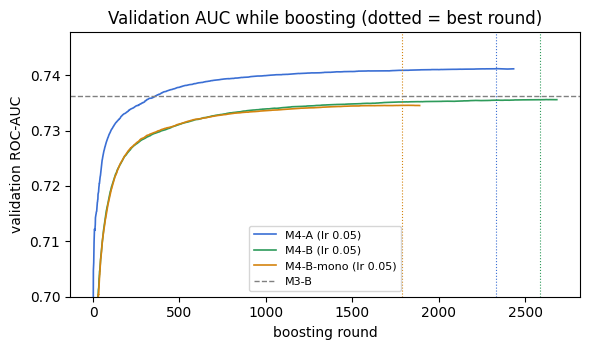

In [10]:
fig, ax = plt.subplots(figsize=(6, 3.6))
for name, color in (("A", "#3b6fd4"), ("B", "#2e9b5b"), ("B-mono", "#d4840f")):
    auc = evals_by_model[name]["validation"]["auc"]
    ax.plot(range(1, len(auc) + 1), auc, color=color, lw=1.2, label=f"M4-{name} (lr {final_lr[name]})")
    ax.axvline(models[name].best_iteration + 1, color=color, ls=":", lw=0.8)
ax.axhline(board_row("M3", "B")["roc_auc"], color="grey", ls="--", lw=1, label="M3-B")
ax.set_xlabel("boosting round"); ax.set_ylabel("validation ROC-AUC"); ax.set_ylim(0.70, None)
ax.set_title("Validation AUC while boosting (dotted = best round)"); ax.legend(fontsize=8); plt.tight_layout()
plt.savefig(RESULTS / "m4_learning_curve.png", dpi=150); plt.show()

## 10. SHAP explanations (version B)
XGBoost computes exact TreeSHAP values (`pred_contribs=True`): per loan, the contributions plus the bias add up to the model's log-odds.

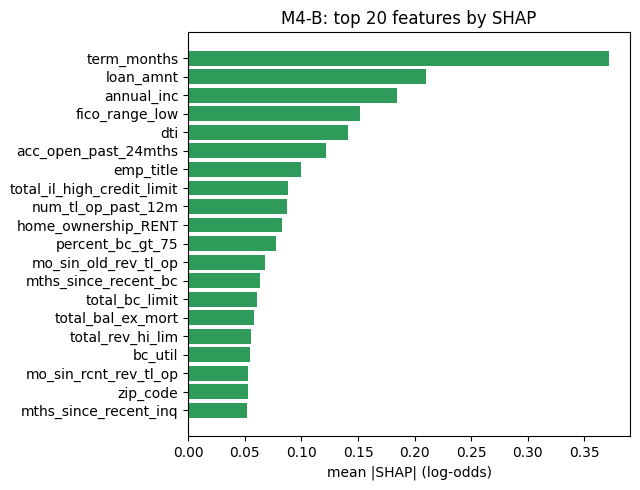

Top-10 SHAP features shared with M3: 9 / 10


,feature,mean_abs_shap,mean_shap,m3_rank
0,term_months,0.3717,-0.0558,1
1,loan_amnt,0.2099,-0.0318,2
2,annual_inc,0.1843,-0.0206,3
3,fico_range_low,0.1515,-0.0108,4
4,dti,0.1415,0.0107,5
5,acc_open_past_24mths,0.1213,0.0115,6
6,emp_title,0.0999,0.0022,7
7,total_il_high_credit_limit,0.0883,-0.0121,11
8,num_tl_op_past_12m,0.0871,0.0072,8
9,home_ownership_RENT,0.0826,-0.0061,10


In [11]:
sample_idx = np.random.default_rng(SEED).choice(len(X_val), size=20000, replace=False)
X_s = X_val.iloc[sample_idx]
contrib = predict(models["B"], "B", X_s, pred_contribs=True)
shap_vals, base_value = contrib[:, :-1], contrib[0, -1]
shap_imp = (pd.DataFrame({"feature": features["B"], "mean_abs_shap": np.abs(shap_vals).mean(axis=0),
                          "mean_shap": shap_vals.mean(axis=0)})
            .sort_values("mean_abs_shap", ascending=False).reset_index(drop=True))
m3_shap = pd.read_csv(ROOT / "models" / "M3_lightgbm" / "results" / "m3_shap_importance.csv")
shap_imp["m3_rank"] = shap_imp["feature"].map({f: i + 1 for i, f in enumerate(m3_shap["feature"])})
top = shap_imp.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.barh(top["feature"], top["mean_abs_shap"], color="#2e9b5b")
ax.set_xlabel("mean |SHAP| (log-odds)"); ax.set_title("M4-B: top 20 features by SHAP"); plt.tight_layout()
plt.savefig(RESULTS / "m4_shap.png", dpi=150); plt.show()
overlap = len(set(shap_imp.head(10)["feature"]) & set(m3_shap.head(10)["feature"]))
print(f"Top-10 SHAP features shared with M3: {overlap} / 10")
shap_imp.head(20).round(4)

In [12]:
pd_s = predict(models["B"], "B", X_s)
row = int(np.flatnonzero(pd_s >= np.quantile(pd_s, 0.9))[0])
contrib_row = pd.Series(shap_vals[row], index=features["B"])
loan = X_s[features["B"]].iloc[row]
example = (pd.DataFrame({"feature": contrib_row.index, "value": loan.values, "shap_log_odds": contrib_row.values})
           .assign(abs_shap=lambda d: d.shap_log_odds.abs()).sort_values("abs_shap", ascending=False).head(8)
           .drop(columns="abs_shap").reset_index(drop=True))
example["direction"] = np.where(example["shap_log_odds"] > 0, "raises risk", "lowers risk")
print(f"Example applicant: PD {pd_s[row]:.1%} (average validation PD {cards['B']['validation']['mean_pd']:.1%}); "
      f"actually defaulted: {bool(y_val[sample_idx][row])}")
print(f"Base log-odds {base_value:.3f} + sum of contributions {contrib_row.sum():.3f} = {base_value + contrib_row.sum():.3f} "
      f"-> PD {1 / (1 + np.exp(-(base_value + contrib_row.sum()))):.1%}")
example.round(4)

Example applicant: PD 55.1% (average validation PD 18.7%); actually defaulted: True
Base log-odds -1.575 + sum of contributions 1.781 = 0.206 -> PD 55.1%


,feature,value,shap_log_odds,direction
0,term_months,60.0000,0.6343,raises risk
1,acc_open_past_24mths,12.0000,0.3715,raises risk
2,fico_range_low,660.0000,0.2260,raises risk
3,emp_title,0.2329,0.1931,raises risk
4,percent_bc_gt_75,11.1000,-0.1726,lowers risk
5,mths_since_recent_bc,1.0000,0.1600,raises risk
6,inq_last_6mths,4.0000,0.1444,raises risk
7,total_il_high_credit_limit,66652.0000,-0.1196,lowers risk


## 11. Calibration on validation

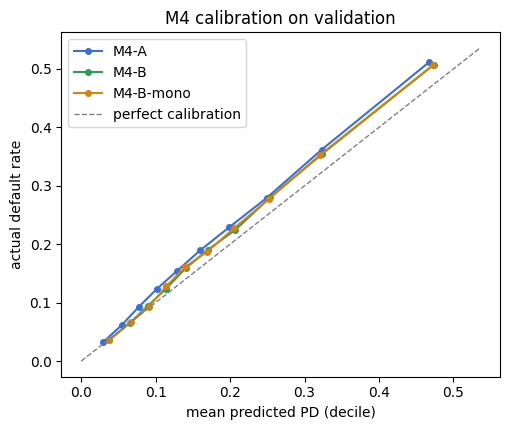

,predicted,actual,model
bin,,,
0,0.0290,0.0320,A
1,0.0545,0.0616,A
2,0.0775,0.0931,A
3,0.1015,0.1234,A
4,0.1283,0.1539,A
5,0.1598,0.1895,A
6,0.1986,0.2288,A
7,0.2493,0.2793,A
8,0.3229,0.3617,A


In [13]:
fig, ax = plt.subplots(figsize=(5.2, 4.4))
calib_rows = []
for name, color in (("A", "#3b6fd4"), ("B", "#2e9b5b"), ("B-mono", "#d4840f")):
    frame = pd.DataFrame({"p": preds[name]["validation"], "y": y_val})
    frame["bin"] = pd.qcut(frame["p"], 10, labels=False, duplicates="drop")
    g = frame.groupby("bin").agg(predicted=("p", "mean"), actual=("y", "mean"))
    ax.plot(g["predicted"], g["actual"], marker="o", color=color, label=f"M4-{name}", ms=4)
    calib_rows.append(g.assign(model=name))
lim = max(ax.get_xlim()[1], ax.get_ylim()[1])
ax.plot([0, lim], [0, lim], ls="--", color="grey", lw=1, label="perfect calibration")
ax.set_xlabel("mean predicted PD (decile)"); ax.set_ylabel("actual default rate")
ax.set_title("M4 calibration on validation"); ax.legend(); plt.tight_layout()
plt.savefig(RESULTS / "m4_calibration.png", dpi=150); plt.show()
pd.concat(calib_rows).round(4)

## 12. Approval-rate vs bad-rate curve (validation, version B)

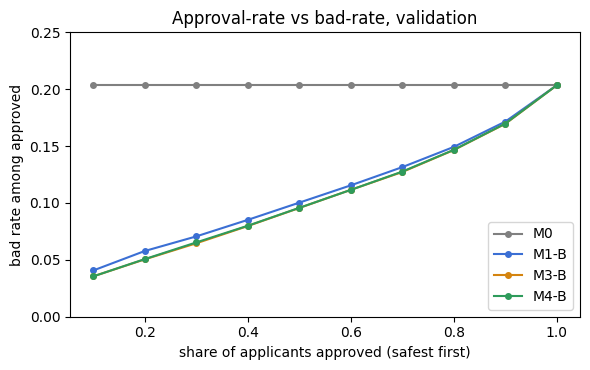

model,M0,M1-B,M3-B,M4-B
approval_rate,,,,
0.1,0.2035,0.0406,0.0355,0.0355
0.2,0.2035,0.0578,0.0504,0.0506
0.3,0.2035,0.0706,0.0645,0.0653
0.4,0.2035,0.0851,0.0797,0.0800
0.5,0.2035,0.1003,0.0956,0.0957
0.6,0.2035,0.1155,0.1115,0.1115
0.7,0.2035,0.1315,0.1272,0.1276
0.8,0.2035,0.1493,0.1465,0.1467
0.9,0.2035,0.1715,0.1696,0.1698


In [14]:
m1_pred = pd.read_parquet(ROOT / "models" / "M1_logistic_regression" / "results" / "m1_B_validation_pd.parquet")
assert (m1_pred["id"].astype(str).to_numpy() == ids).all()
curves = pd.concat([
    ev.approval_curve(y_val, np.full(len(y_val), m0["mean_pd"])).assign(model="M0"),
    ev.approval_curve(y_val, m1_pred["pd_m1_B"].to_numpy()).assign(model="M1-B"),
    ev.approval_curve(y_val, m3_pred["pd_m3_B"].to_numpy()).assign(model="M3-B"),
    ev.approval_curve(y_val, preds["B"]["validation"]).assign(model="M4-B"),
])
fig, ax = plt.subplots(figsize=(6, 3.8))
for name, color in (("M0", "grey"), ("M1-B", "#3b6fd4"), ("M3-B", "#d4840f"), ("M4-B", "#2e9b5b")):
    part = curves[curves.model == name]
    ax.plot(part["approval_rate"], part["bad_rate_among_approved"], marker="o", ms=4, color=color, label=name)
ax.set_xlabel("share of applicants approved (safest first)"); ax.set_ylabel("bad rate among approved")
ax.set_title("Approval-rate vs bad-rate, validation"); ax.legend(); ax.set_ylim(0, 0.25); plt.tight_layout()
plt.savefig(RESULTS / "m4_approval_curve.png", dpi=150); plt.show()
curves.pivot(index="approval_rate", columns="model", values="bad_rate_among_approved").round(4)

## 13. Segments, A vs B, and the cost of monotonic constraints

In [15]:
segments = pd.concat([
    ev.segment_report(y_val, preds[name]["validation"], X_val["term_months"], "term_months").assign(model=name)
    for name in models
])
a, b, bm_ = cards["A"]["validation"], cards["B"]["validation"], cards["B-mono"]["validation"]
print(f"A minus B: ROC-AUC {a['roc_auc'] - b['roc_auc']:+.4f}; B keeps {(b['roc_auc'] - 0.5) / (a['roc_auc'] - 0.5):.1%} "
      "of A's ranking power above a coin flip")
print(f"B-mono minus B: ROC-AUC {bm_['roc_auc'] - b['roc_auc']:+.4f}, Brier {bm_['brier'] - b['brier']:+.4f}")
segments[["model", "term_months", "rows", "default_rate", "mean_pd", "calibration_gap", "roc_auc", "ks", "brier"]].round(4)

A minus B: ROC-AUC +0.0056; B keeps 97.7% of A's ranking power above a coin flip
B-mono minus B: ROC-AUC -0.0010, Brier +0.0002


,model,term_months,rows,default_rate,mean_pd,calibration_gap,roc_auc,ks,brier
0,A,36.0,120790,0.1512,0.1349,-0.0163,0.7090,0.3059,0.1193
1,A,60.0,41955,0.3540,0.3056,-0.0484,0.6882,0.2764,0.2084
0,B,36.0,120790,0.1512,0.1430,-0.0083,0.7002,0.2931,0.1200
1,B,60.0,41955,0.3540,0.3154,-0.0385,0.6847,0.2682,0.2083
0,B-mono,36.0,120790,0.1512,0.1424,-0.0089,0.6984,0.2893,0.1202
1,B-mono,60.0,41955,0.3540,0.3151,-0.0389,0.6844,0.2685,0.2084


## 14. Save results

In [16]:
tuning.to_csv(RESULTS / "m4_tuning_results.csv", index=False)
experiments.to_csv(RESULTS / "m4_experiments.csv", index=False)
h2h.to_csv(RESULTS / "m4_vs_m3.csv", index=False)
shap_imp.to_csv(RESULTS / "m4_shap_importance.csv", index=False)
example.to_csv(RESULTS / "m4_example_explanation.csv", index=False)
segments.to_csv(RESULTS / "m4_segment_metrics.csv", index=False)
curves.to_csv(RESULTS / "m4_approval_curve.csv", index=False)
pd.DataFrame({"id": ids, **{f"pd_m4_{n.replace('-', '_')}": preds[n]["validation"] for n in models}}).to_parquet(
    RESULTS / "m4_validation_pd.parquet", index=False)
for name, booster in models.items():
    booster.save_model(str(RESULTS / f"m4_{name.replace('-', '_')}.ubj"))
summary = {
    "model": "M4", "name": "XGBoost", "estimator": "xgboost.train (gbtree, hist)",
    "fixed_parameters": {k: v for k, v in BASE.items() if k != "nthread"},
    "search": {"type": "random search", "settings_per_version": N_TRIALS, "learning_rate": SEARCH_LR,
               "early_stopping_rounds": EARLY_STOP, "max_rounds": MAX_ROUNDS,
               "ranges": {"max_depth": [3, 10], "min_child_weight": [1, 200], "subsample": [0.5, 1.0],
                          "colsample_bytree": [0.4, 1.0], "reg_lambda": [1e-3, 10], "reg_alpha": [1e-4, 10], "gamma": [0, 1]}},
    "selection_rule": "max validation ROC-AUC; within 0.0005 prefer smaller max_depth; lr 0.02 kept only if +0.0005",
    "chosen": chosen, "final_learning_rate": final_lr,
    "best_iteration": {n: int(b.best_iteration + 1) for n, b in models.items()},
    "final_fit_seconds": {n: round(s, 1) for n, s in fit_seconds.items()},
    "scale_pos_weight_tested": spw, "monotone_constraints": MONOTONE,
    "n_features": {v: len(features[v]) for v in ("A", "B")},
    "environment": {"python": platform.python_version(), "pandas": pd.__version__, "scikit_learn": sklearn.__version__,
                    "xgboost": xgb.__version__, "platform": "Kaggle CPU notebook" if ON_KAGGLE else "local",
                    "cpu_cores": os.cpu_count()},
    "metrics": cards, "test_split": "sealed",
}
(RESULTS / "m4_metrics.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
for name in models:
    cfg = chosen["B" if name == "B-mono" else name]
    note = (f"lr={final_lr[name]}, rounds={models[name].best_iteration + 1}, depth={cfg['max_depth']}, "
            f"min_child_weight={cfg['min_child_weight']:.3g}" + (", monotone" if name == "B-mono" else ""))
    for split in ("train", "validation"):
        board = ev.update_leaderboard("M4", name, split, cards[name][split], notes=note)
print("Saved:", sorted(p.name for p in RESULTS.iterdir()))
board[board.split == "validation"].round(4)

Saved: ['m4_A.ubj', 'm4_B.ubj', 'm4_B_mono.ubj', 'm4_approval_curve.csv', 'm4_approval_curve.png', 'm4_calibration.png', 'm4_example_explanation.csv', 'm4_experiments.csv', 'm4_learning_curve.png', 'm4_metrics.json', 'm4_segment_metrics.csv', 'm4_shap.png', 'm4_shap_importance.csv', 'm4_tuning_results.csv', 'm4_validation_pd.parquet', 'm4_vs_m3.csv']


,model,version,split,rows,default_rate,mean_pd,roc_auc,pr_auc,ks,brier,log_loss,calibration_gap,notes
1,M0,A,validation,162745,0.2035,0.1724,0.5000,0.2035,0.0000,0.1631,0.5085,-0.0311,constant PD = train default rate
3,M0,B,validation,162745,0.2035,0.1724,0.5000,0.2035,0.0000,0.1631,0.5085,-0.0311,constant PD = train default rate
5,M1,A,validation,162745,0.2035,0.1773,0.7335,0.4120,0.3421,0.1445,0.4506,-0.0262,"log+scale, C=0.0001, class_weight=None"
7,M1,B,validation,162745,0.2035,0.1837,0.7252,0.4045,0.3262,0.1449,0.4529,-0.0198,"log+scale, C=0.001, class_weight=None"
9,M2,A,validation,162745,0.2035,0.1749,0.7345,0.4152,0.3410,0.1443,0.4503,-0.0286,"500 trees, leaf=50, max_features=0.3, class_we..."
11,M2,B,validation,162745,0.2035,0.1817,0.7270,0.4084,0.3284,0.1467,0.4571,-0.0218,"500 trees, leaf=20, max_features=sqrt, class_w..."
13,M3,A,validation,162745,0.2035,0.1792,0.7414,0.4250,0.3519,0.1422,0.4448,-0.0243,"lr=0.02, rounds=2961, leaves=20, min_leaf=442"
15,M3,B,validation,162745,0.2035,0.1869,0.7362,0.4210,0.3415,0.1426,0.4463,-0.0167,"lr=0.02, rounds=2279, leaves=21, min_leaf=1433"
17,M3,B-mono,validation,162745,0.2035,0.1870,0.7354,0.4201,0.3400,0.1428,0.4467,-0.0165,"lr=0.02, rounds=1853, leaves=21, min_leaf=1433..."
19,M4,A,validation,162745,0.2035,0.1789,0.7412,0.4248,0.3517,0.1423,0.4450,-0.0246,"lr=0.05, rounds=2334, depth=3, min_child_weigh..."


## 15. Conclusion

In [17]:
for v in ("A", "B"):
    print(f"Version {v}: ROC-AUC M1 {board_row('M1', v)['roc_auc']:.4f} | M3 {board_row('M3', v)['roc_auc']:.4f} | "
          f"M4 {cards[v]['validation']['roc_auc']:.4f};  Brier M3 {board_row('M3', v)['brier']:.4f} | M4 {cards[v]['validation']['brier']:.4f}")
diff = cards["B"]["validation"]["roc_auc"] - board_row("M3", "B")["roc_auc"]
if diff > 0.005:
    verdict = f"XGBoost clearly beats LightGBM on version B ({diff:+.4f} ROC-AUC): M4 becomes the main candidate."
elif diff < -0.005:
    verdict = f"XGBoost is clearly worse than LightGBM on version B ({diff:+.4f} ROC-AUC): M3 stays the main candidate."
else:
    verdict = (f"XGBoost and LightGBM are within 0.005 ROC-AUC on version B ({diff:+.4f}): the boosting gain over "
               "Logistic Regression is confirmed by a second library, and the faster / simpler model should be kept.")
print("\nVerdict:", verdict)

Version A: ROC-AUC M1 0.7335 | M3 0.7414 | M4 0.7412;  Brier M3 0.1422 | M4 0.1423
Version B: ROC-AUC M1 0.7252 | M3 0.7362 | M4 0.7356;  Brier M3 0.1426 | M4 0.1427

Verdict: XGBoost and LightGBM are within 0.005 ROC-AUC on version B (-0.0006): the boosting gain over Logistic Regression is confirmed by a second library, and the faster / simpler model should be kept.
